<a href="https://colab.research.google.com/github/aeslha/DSRP/blob/main/Research_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Debt Has a Minimal Impact on Nominal GDP Growth

In [ ]:
import warnings
warnings.filterwarnings('ignore')

!pip install pandas
import pandas as pd

!pip install numpy
import numpy as np

!pip install matplotlib
import matplotlib.pyplot as plt

!pip install scikit-learn
from sklearn import datasets, model_selection, metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import *
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/aeslha/july_21/refs/heads/main/GlobalDebtDatabase.csv')
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Year,"Total private debt, \nall instruments\n(percen...","Total private debt, \nloans and debt securitie...","Household debt, all instruments\n(percent of GDP)","Household debt, loans and debt securities\n(pe...","Non-financial corporations debt, all instrumen...","Non-financial corporations debt, loans and deb...",Public sector debt\n(percent of GDP),Nonfinancial public sector debt\n(percent of GDP),General government debt\n(percent of GDP),Central government debt\n(percent of GDP),Nominal gross domestic product\n(billions),NaN
2,NaN,1950,75.83,55.31,25.48,24.80,50.34,30.51,NaN,NaN,83.13,78.20,301.78,NaN
3,NaN,1951,72.69,53.66,24.52,23.91,48.17,29.75,NaN,NaN,72.96,68.20,348.99,NaN
4,NaN,1952,88.24,56.56,26.60,25.98,61.64,30.58,NaN,NaN,72.53,66.34,368.03,NaN


**DATA CLEANING**

In [ ]:
# dropping columns will only null values
df.drop(['Unnamed: 0', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 13'], axis=1, inplace=True)
# dropping the first row of only null values
df.drop(0, axis=0, inplace = True)
# Renaming columns
df = df.rename(columns={'Unnamed: 1': 'Year', 'Unnamed: 2': 'Total Private Debt Of All Instruments', 'Unnamed: 3': 'Total Private Debt Of Loans And Securities', 'Unnamed: 4': 'Household Debt Of All Intruments', 'Unnamed: 5': 'Household Debt, Loans and Debt Securities', 'Unnamed: 6': 'Non-Financial Corporations Debt Of All Instruments', 'Unnamed: 7': 'Non Financial Corperations Debt, loans and Debt Securities', 'Unnamed: 10': 'General Government Debt', 'Unnamed: 11': 'Central Government Debt', 'Unnamed: 12': 'Nominal GDP' })
df.drop(1, axis=0, inplace = True)
df.head()

,Year,Total Private Debt Of All Instruments,Total Private Debt Of Loans And Securities,Household Debt Of All Intruments,"Household Debt, Loans and Debt Securities",Non-Financial Corporations Debt Of All Instruments,"Non Financial Corperations Debt, loans and Debt Securities",General Government Debt,Central Government Debt,Nominal GDP
2,1950,75.83,55.31,25.48,24.80,50.34,30.51,83.13,78.20,301.78
3,1951,72.69,53.66,24.52,23.91,48.17,29.75,72.96,68.20,348.99
4,1952,88.24,56.56,26.60,25.98,61.64,30.58,72.53,66.34,368.03
5,1953,88.05,58.02,28.43,27.79,59.62,30.22,71.75,64.60,389.15
6,1954,106.06,62.57,31.54,30.86,74.52,31.71,73.57,64.96,390.28


In [ ]:
# changing dtypes to numeric
df = df.astype({'Year': 'int'})
float_cols = df.select_dtypes(include=['object']).columns
df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 2 to 75
Data columns (total 10 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   Year                                                        74 non-null     int64  
 1   Total Private Debt Of All Instruments                       74 non-null     float64
 2   Total Private Debt Of Loans And Securities                  74 non-null     float64
 3   Household Debt Of All Intruments                            74 non-null     float64
 4   Household Debt, Loans and Debt Securities                   74 non-null     float64
 5   Non-Financial Corporations Debt Of All Instruments          74 non-null     float64
 6   Non Financial Corperations Debt, loans and Debt Securities  74 non-null     float64
 7   General Government Debt                                     74 non-null     float64
 8   Ce

In [ ]:
# dropping first 50 rows (years) to only see data from and post the year 2000.
df=df.drop(df.index[0:49])

In [ ]:
df['Nominal GDP Growth'] = df['Nominal GDP'].pct_change() * 100  # % change year-over-year
df = df.dropna(subset=['Nominal GDP Growth']) # drops the first null value
avg_growth = df['Nominal GDP Growth'].mean()  # get average growth rate
print(avg_growth)
df.head(24)

4.538214484829136


,Year,Total Private Debt Of All Instruments,Total Private Debt Of Loans And Securities,Household Debt Of All Intruments,"Household Debt, Loans and Debt Securities",Non-Financial Corporations Debt Of All Instruments,"Non Financial Corperations Debt, loans and Debt Securities",General Government Debt,Central Government Debt,Nominal GDP,Nominal GDP Growth
52,2000,196.44,136.74,72.48,70.85,123.96,65.90,54.64,41.38,10250.95,6.435037
53,2001,203.22,141.41,76.28,74.71,126.94,66.70,54.53,40.66,10581.93,3.228774
54,2002,209.16,145.62,81.14,79.45,128.02,66.17,56.94,42.12,10929.10,3.280781
55,2003,206.66,149.35,86.99,85.27,119.67,64.08,59.82,44.68,11456.45,4.825191
56,2004,210.47,153.24,90.98,89.22,119.49,64.02,67.29,45.48,12217.18,6.640190
57,2005,216.52,157.57,94.51,92.73,122.02,64.84,67.13,45.61,13039.20,6.728394
58,2006,222.89,164.09,98.71,96.92,124.18,67.17,65.91,44.83,13815.60,5.954353
59,2007,230.98,170.86,100.59,98.74,130.38,72.12,66.25,45.17,14474.25,4.767437
60,2008,235.93,170.76,98.15,96.15,137.79,74.61,74.97,53.41,14769.85,2.042247
61,2009,235.52,169.54,99.24,96.96,136.29,72.59,87.80,64.97,14478.05,-1.975646


# Abstract

Nominal GDP has changed drastically over the years, specifically during the years 2000 and 2023. The changes in growth are influenced by multiple variables, with debt being the primary focus of this research. How well does debt truly impact nominal GDP growth? To find this correlation, the software Google Colab and the coding language Python were utilized. To categorize the various types of debt in the database, both total private debt and general government debt were used. As a result of exploratory data analysis, there is no significant trend for Nominal GDP Growth, except during every major economic crisis in the U.S., where growth decreased rapidly. Additionally, with the constant change of Nominal GDP Growth, there was a continuous increase in public debt as well as in private debt.
In conclusion, the most significant results came from the linear regression models. These showed that when using public and/or private debt to predict Nominal GDP Growth, there was almost no overlap. Thus, it is concluded that debt alone has a minimal impact on Nominal GDP Growth.


# Background

This research aims to answer the question: How Did Rising U.S Public and
Private Debt After 2000 Presidential
Election Correlate With Changes in
Nominal GDP Growth Between 2001
And 2023? Nominal GDP Growth is the increase in
the total market price of all goods and
services in a specific year without
adjusting for inflation. For the purpose of this research Public debt includes data from the General Government Debt of the U.S and Private debt includes data from Total Household Debt + Total Non-Financial Cooperation's Debt from the U.S. The data was taken from the internantional monetary fund data base.

# Results

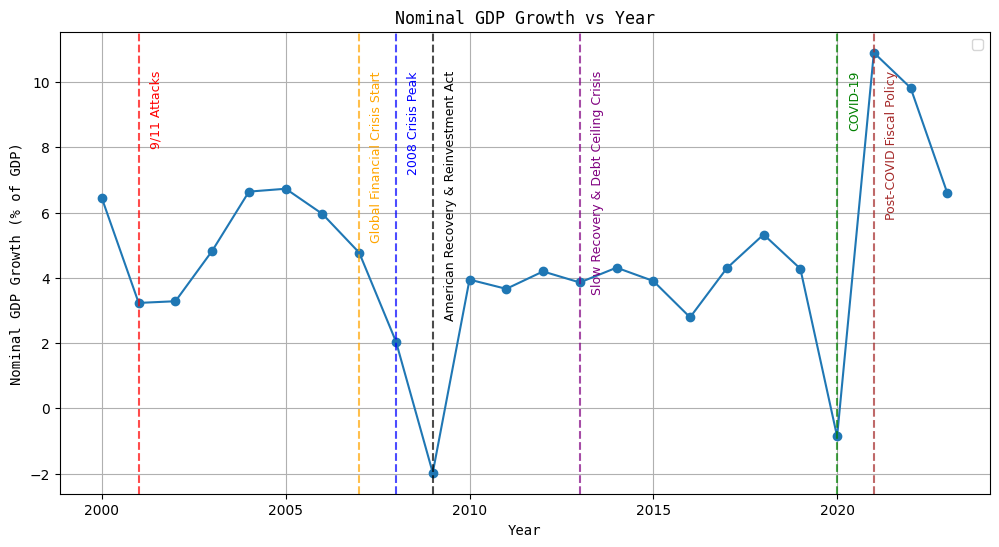

In [ ]:
# seeing how nominal gdp has changed over the years
plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['Nominal GDP Growth'], marker = 'o')
plt.xlabel('Year', fontname = 'monospace')
plt.ylabel('Nominal GDP Growth (% of GDP)', fontname = 'monospace')
plt.title('Nominal GDP Growth vs Year', fontname = 'monospace')
events = [
    (2001, '9/11 Attacks', 'red'),
    (2007, 'Global Financial Crisis Start', 'orange'),
    (2008, '2008 Crisis Peak', 'blue'),
    (2009, 'American Recovery & Reinvestment Act', 'black'),
    (2013, 'Slow Recovery & Debt Ceiling Crisis', 'purple'),
    (2020, 'COVID-19', 'green'),
    (2021, 'Post-COVID Fiscal Policy', 'brown'),]

for year, label, color in events:
    plt.axvline(x=year, color=color, linestyle='--', alpha=0.7)
    plt.text(year + 0.3, df['Nominal GDP Growth'].max() * 0.95, label,
             color=color, rotation=90, verticalalignment='top', fontsize=9)

plt.grid(True)
plt.legend()
plt.show()

Figure 1.1: This graph displays how Nominal GDP Growth has consistently increased over time with a few years of a drop in GDP. You can see that during the 2008 financial crisis GDP dropped as well during the Covid-19 pandemic.

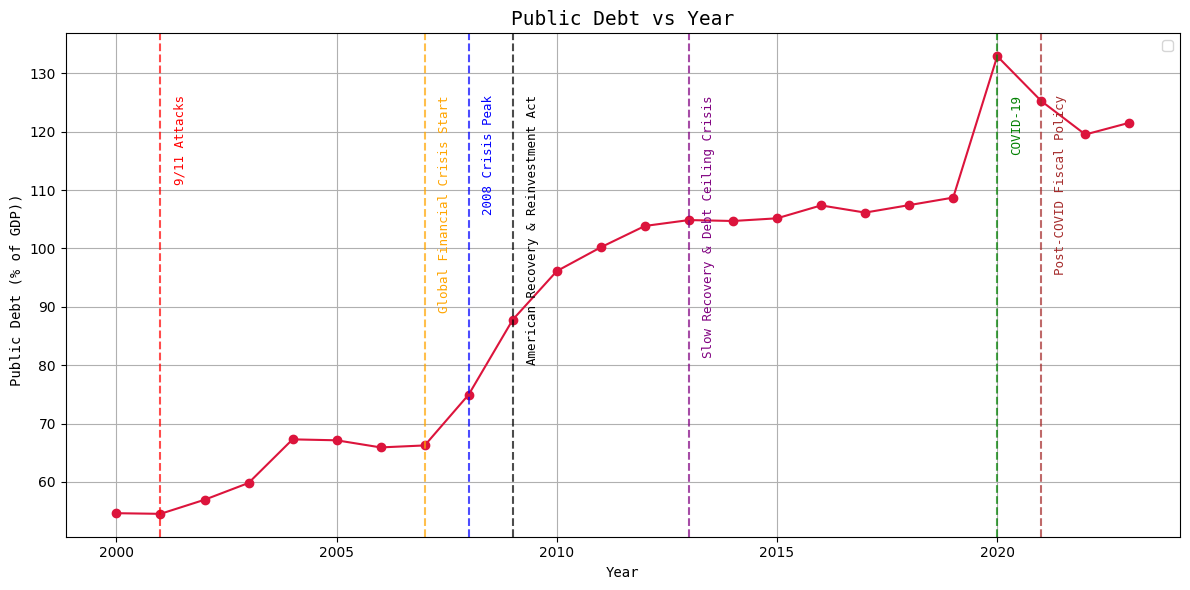

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df['Year'], df['General Government Debt'], color='crimson', marker='o', )
plt.title('Public Debt vs Year', fontsize=14, fontname = 'monospace')
plt.xlabel('Year',  fontname = 'monospace')
plt.ylabel('Public Debt (% of GDP)) ', fontname = 'monospace')

events = [
    (2001, '9/11 Attacks', 'red'),
    (2007, 'Global Financial Crisis Start', 'orange'),
    (2008, '2008 Crisis Peak', 'blue'),
    (2009, 'American Recovery & Reinvestment Act', 'black'),
    (2013, 'Slow Recovery & Debt Ceiling Crisis', 'purple'),
    (2020, 'COVID-19', 'green'),
    (2021, 'Post-COVID Fiscal Policy', 'brown'),]

for year, label, color in events:
    plt.axvline(x=year, color=color, linestyle='--', alpha=0.7)
    plt.text(year + 0.3, df['General Government Debt'].max() * 0.95, label,
             color=color, rotation=90, verticalalignment='top', fontsize=9, fontname = 'monospace')

plt.grid(True)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Figure 1.2: This graph explains how public debt or federal government debt does not have one specific trend over time. Instead during specific time periods the debt either increased greatly or decreased greatly. Additionally, the average debt growth has also changed during different presidential terms.               

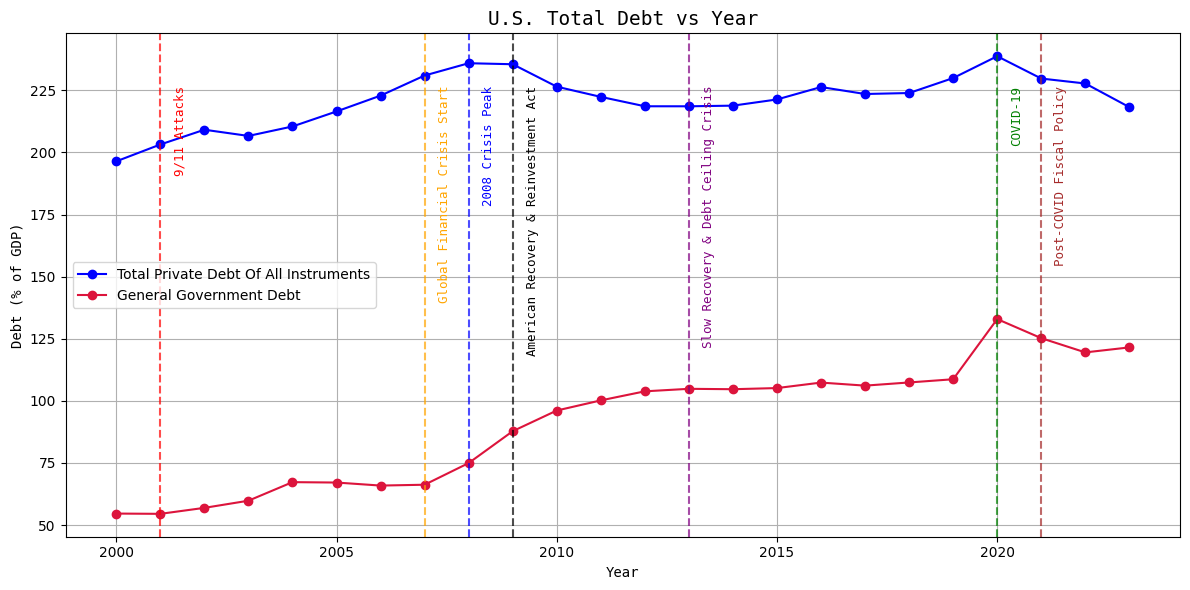

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df['Year'], df['Total Private Debt Of All Instruments'], color='blue', marker = 'o', label='Total Private Debt Of All Instruments')
plt.plot(df['Year'], df['General Government Debt'], color='crimson', marker='o', label='General Government Debt' )
plt.title('U.S. Total Debt vs Year', fontsize=14, fontname = 'monospace')
plt.xlabel('Year', fontname = 'monospace')
plt.ylabel('Debt (% of GDP)', fontname = 'monospace')

events = [
    (2001, '9/11 Attacks', 'red'),
    (2007, 'Global Financial Crisis Start', 'orange'),
    (2008, '2008 Crisis Peak', 'blue'),
    (2009, 'American Recovery & Reinvestment Act', 'black'),
    (2013, 'Slow Recovery & Debt Ceiling Crisis', 'purple'),
    (2020, 'COVID-19', 'green'),
    (2021, 'Post-COVID Fiscal Policy', 'brown'),
]

for year, label, color in events:
    plt.axvline(x=year, color=color, linestyle='--', alpha=0.7)
    plt.text(year + 0.3, df['Total Private Debt Of All Instruments'].max() * 0.95, label,
             color=color, rotation=90, verticalalignment='top', fontsize=9, fontname = 'monospace')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


Figure 1.3: This graph shows how private debt in the U.S has changed since the year 2000. As you can see theres no constant trend and the percent of debt increases and decreases at different time periods. A specific moment you can see is that during 2008 financial crisis and 2020 pandemic crisis had the highest amount of debt. On the other hand, during the recovey periods you can see the percent of debt decreased rapidly.

# **LINEAR REGRESSION**

# Classification

In [ ]:
df.head()

,Year,Total Private Debt Of All Instruments,Total Private Debt Of Loans And Securities,Household Debt Of All Intruments,"Household Debt, Loans and Debt Securities",Non-Financial Corporations Debt Of All Instruments,"Non Financial Corperations Debt, loans and Debt Securities",General Government Debt,Central Government Debt,Nominal GDP,Nominal GDP Growth
52,2000,196.44,136.74,72.48,70.85,123.96,65.90,54.64,41.38,10250.95,6.435037
53,2001,203.22,141.41,76.28,74.71,126.94,66.70,54.53,40.66,10581.93,3.228774
54,2002,209.16,145.62,81.14,79.45,128.02,66.17,56.94,42.12,10929.10,3.280781
55,2003,206.66,149.35,86.99,85.27,119.67,64.08,59.82,44.68,11456.45,4.825191
56,2004,210.47,153.24,90.98,89.22,119.49,64.02,67.29,45.48,12217.18,6.640190


In [ ]:
#df['Check_Total_Private'] = df['Household Debt Of All Intruments'] + df['Non-Financial Corporations Debt Of All Instruments']

# Compare with Total Private Debt
#df[['Total Private Debt Of All Instruments', 'Check_Total_Private']].head()


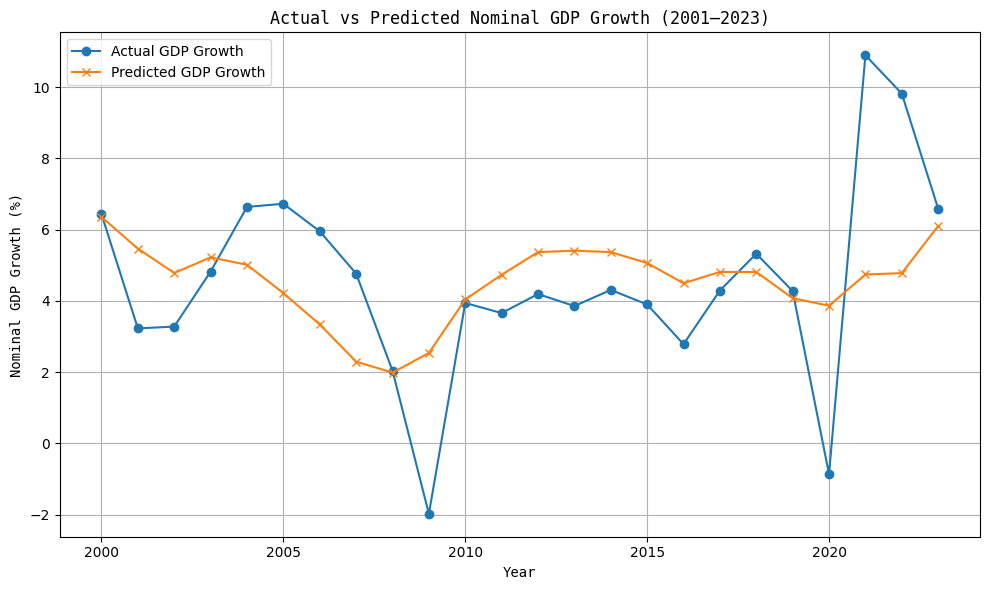

Intercept: 29.898408286316155
Coefficients: [-0.13062127  0.03877143]
R^2 Score: 0.16081221960120595


In [ ]:
X = df[['Total Private Debt Of All Instruments', 'General Government Debt']]
y = df['Nominal GDP Growth']

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

plt.figure(figsize=(10, 6))
plt.plot(df['Year'], y, label='Actual GDP Growth', marker='o')
plt.plot(df['Year'], pred, label='Predicted GDP Growth', marker='x')
plt.xlabel('Year', fontname = 'monospace')
plt.ylabel('Nominal GDP Growth (%)', fontname = 'monospace')
plt.title('Actual vs Predicted Nominal GDP Growth (2001–2023)', fontname = 'monospace')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R^2 Score:", model.score(X, y))


Figure 2.1: When considering public and private debt simultaneously, private debt shows a stronger negative correlation with GDP growth, with a relative decrease of approximately 2.9%. In comparison, public debt has a slight positive correlation with a relative increase of about 0.86%. The combined model fits the data better than models with either variable alone.

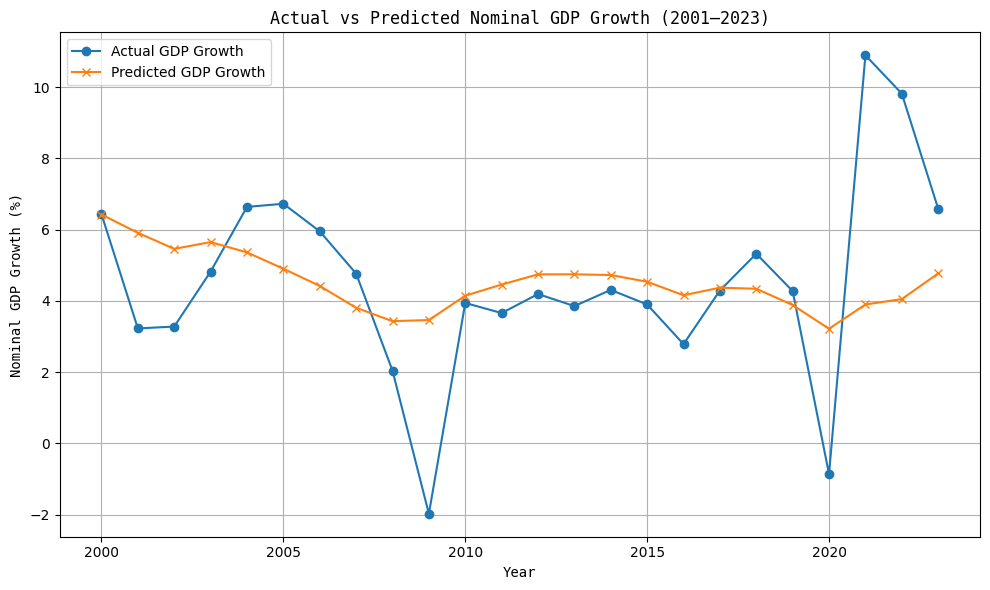

Intercept: 21.319910657440804
Coefficients: [-0.07581606]
R^2 Score: 0.08385704766819613


In [ ]:
X = df[['Total Private Debt Of All Instruments']]
y = df['Nominal GDP Growth']

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

plt.figure(figsize=(10, 6))
plt.plot(df['Year'], y, label='Actual GDP Growth', marker='o')
plt.plot(df['Year'], pred, label='Predicted GDP Growth', marker='x')
plt.xlabel('Year', fontname = 'monospace')
plt.ylabel('Nominal GDP Growth (%)', fontname = 'monospace')
plt.title('Actual vs Predicted Nominal GDP Growth (2001–2023)', fontname = 'monospace')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R^2 Score:", model.score(X, y))

Figure 2.2: Private debt alone negatively correlates with GDP Growth. Specifically, with every 1% increase in private debt, there is a 1.68% decrease in GDP growth relative to the average growth rate. There is also an r^2 value of 8.4% which suggests that private debt alone accounts for about 8.4% of the differences in GDP growth over this period.


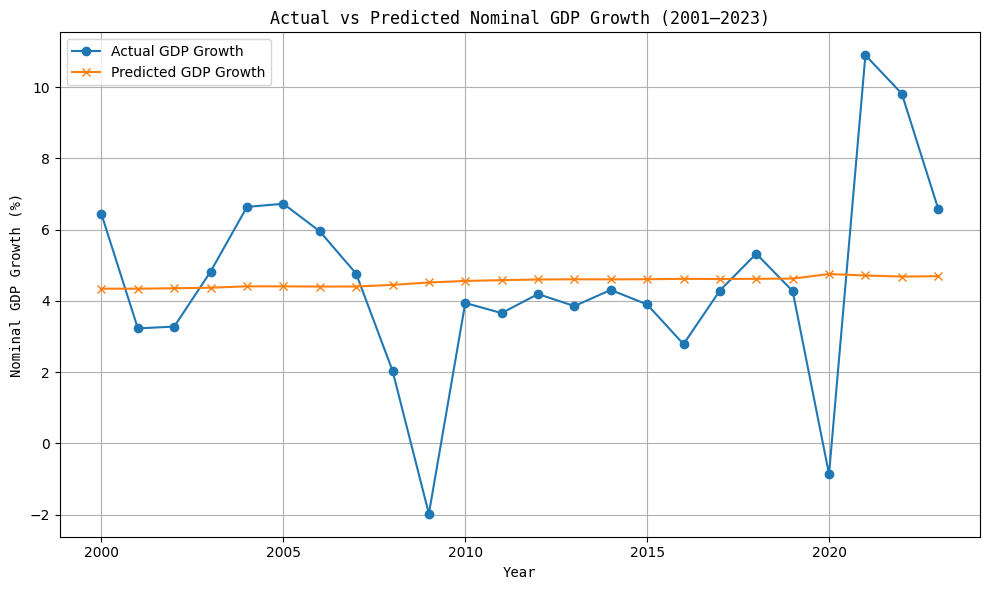

Intercept: 4.057659972098046
Coefficients: [0.0052447]
R^2 Score: 0.0022099949354303927


In [ ]:
X = df[['General Government Debt']]
y = df['Nominal GDP Growth']

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)

plt.figure(figsize=(10, 6))
plt.plot(df['Year'], y, label='Actual GDP Growth', marker='o')
plt.plot(df['Year'], pred, label='Predicted GDP Growth', marker='x')
plt.xlabel('Year', fontname = 'monospace')
plt.ylabel('Nominal GDP Growth (%)', fontname = 'monospace')
plt.title('Actual vs Predicted Nominal GDP Growth (2001–2023)', fontname = 'monospace')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("R^2 Score:", model.score(X, y))

Figure 2.3: Public debt alone has a small positive effect on GDP Growth. Specifically, with every 1% increase in public debt, there is approximately a 0.12% increase in GDP Growth relative to the average growth rate. Additionally, it also explains almost no variation in GDP Growth on its own with an R^2 of 0.22%.


# Discussion

Examining debt alone reveals
a minimal impact on GDP Growth, indicating
a slight correlation between the two; This is
seen through predictions from linear regression models and exploratory data analysis. However, to better understand
and predict GDP growth, it would be
beneficial to include additional variables such
as unemployment, interest rates & inflation,
which will likely contribute more significantly
to explaining its variability.


## Code and Data Availability


*   Git Repasitory: https://github.com/aeslha/DSRP
*   Database: https://www.imf.org/external/datamapper/datasets/GDD




## Acknowledgements:
I would like to acknowledge my TA Manasa
as well as my mentor Peguy Kem-Meka
Tiotsop Kadzue for their help and guidance throughout researching and creating this project.